<a href="https://colab.research.google.com/github/Tolegithub7/ml_labs/blob/main/PythonAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
# This lab exercise involves creating a graph library, implementing search algorithms, analyzing their performance, and designing a robotic simulator.

In [14]:
# Construct Graph

import csv

class Graph:
    def __init__(self):
        self.nodes = set()
        self.edges = {}
        self.distances = {}

    def add_node(self, value):
        self.nodes.add(value)
        self.edges[value] = []

    def add_edge(self, from_node, to_node, distance):
        if from_node in self.nodes and to_node in self.nodes:
            self.edges[from_node].append(to_node)
            self.edges[to_node].append(from_node)
            self.distances[(from_node, to_node)] = distance
            self.distances[(to_node, from_node)] = distance

    def remove_node(self, value):
        if value in self.nodes:
            self.nodes.remove(value)
            self.edges.pop(value, None)
            self.distances = {k: v for k, v in self.distances.items() if value not in k}
            for edge_list in self.edges.values():
                if value in edge_list:
                    edge_list.remove(value)

    def remove_edge(self, from_node, to_node):
        if from_node in self.nodes and to_node in self.nodes:
            if to_node in self.edges[from_node]:
                self.edges[from_node].remove(to_node)
            if from_node in self.edges[to_node]:
                self.edges[to_node].remove(from_node)
            self.distances.pop((from_node, to_node), None)
            self.distances.pop((to_node, from_node), None)

# Load Romania map coordinates from CSV file
def load_romania_map(filename):
    graph = Graph()
    with open(filename, mode='r') as infile:
        reader = csv.reader(infile)
        next(reader)  # Skip header
        for row in reader:
            city = row[0]
            graph.add_node(city)
    return graph

# Example usage
romania_graph = load_romania_map('romania_coordinates.csv')
romania_graph.add_edge('Arad', 'Zerind', 75)
romania_graph.add_edge('Arad', 'Timisoara', 118)
romania_graph.add_edge('Zerind', 'Oradea', 71)
romania_graph.add_edge('Timisoara', 'Lugoj', 111)
romania_graph.add_edge('Lugoj', 'Mehadia', 70)
romania_graph.add_edge('Mehadia', 'Drobeta', 75)
romania_graph.add_edge('Drobeta', 'Craiova', 120)
romania_graph.add_edge('Craiova', 'Pitesti', 138)
romania_graph.add_edge('Pitesti', 'Bucharest', 101)
romania_graph.add_edge('Bucharest', 'Giurgiu', 90)
romania_graph.add_edge('Bucharest', 'Urziceni', 85)
romania_graph.add_edge('Urziceni', 'Hirsova', 98)
romania_graph.add_edge('Hirsova', 'Eforie', 86)
romania_graph.add_edge('Urziceni', 'Vaslui', 142)
romania_graph.add_edge('Vaslui', 'Iasi', 92)
romania_graph.add_edge('Iasi', 'Neamt', 87)
romania_graph.add_edge('Arad', 'Sibiu', 140)
romania_graph.add_edge('Sibiu', 'Fagaras', 99)
romania_graph.add_edge('Sibiu', 'Rimnicu Vilcea', 80)
romania_graph.add_edge('Rimnicu Vilcea', 'Pitesti', 97)
romania_graph.add_edge('Rimnicu Vilcea', 'Craiova', 146)
romania_graph.add_edge('Fagaras', 'Bucharest', 211)

In [15]:
class Node:
    def __init__(self, name):
        self.name = name
        self.adjacency_list = []

    def add_edge(self, neighbor, distance):
        self.adjacency_list.append((neighbor, distance))

# Example usage
arad = Node('Arad')
zerind = Node('Zerind')
arad.add_edge(zerind, 75)

print(f"Node: {arad.name}, Edges: {[(neighbor.name, distance) for neighbor, distance in arad.adjacency_list]}")

Node: Arad, Edges: [('Zerind', 75)]


In [18]:
# Insert and Delete Edges and Nodes

class Graph:
    def __init__(self):
        self.nodes = set()
        self.edges = {}
        self.distances = {}

    def add_node(self, value):
        self.nodes.add(value)
        self.edges[value] = []

    def add_edge(self, from_node, to_node, distance):
        if from_node in self.nodes and to_node in self.nodes:
            self.edges[from_node].append(to_node)
            self.edges[to_node].append(from_node)
            self.distances[(from_node, to_node)] = distance
            self.distances[(to_node, from_node)] = distance

    def remove_node(self, value):
        if value in self.nodes:
            self.nodes.remove(value)
            self.edges.pop(value, None)
            self.distances = {k: v for k, v in self.distances.items() if value not in k}
            for edge_list in self.edges.values():
                if value in edge_list:
                    edge_list.remove(value)

    def remove_edge(self, from_node, to_node):
        if from_node in self.nodes and to_node in self.nodes:
            if to_node in self.edges[from_node]:
                self.edges[from_node].remove(to_node)
            if from_node in self.edges[to_node]:
                self.edges[to_node].remove(from_node)
            self.distances.pop((from_node, to_node), None)
            self.distances.pop((to_node, from_node), None)

# Example usage
romania_graph = Graph()
romania_graph.add_node('Arad')
romania_graph.add_node('Zerind')
romania_graph.add_edge('Arad', 'Zerind', 75)

print(f"Nodes: {romania_graph.nodes}")
print(f"Edges: {romania_graph.edges}")
print(f"Distances: {romania_graph.distances}")

romania_graph.remove_edge('Arad', 'Zerind')
print(f"Edges after removing edge: {romania_graph.edges}")

romania_graph.remove_node('Zerind')
print(f"Nodes after removing node: {romania_graph.nodes}")
print(f"Edges after removing node: {romania_graph.edges}")

Nodes: {'Zerind', 'Arad'}
Edges: {'Arad': ['Zerind'], 'Zerind': ['Arad']}
Distances: {('Arad', 'Zerind'): 75, ('Zerind', 'Arad'): 75}
Edges after removing edge: {'Arad': [], 'Zerind': []}
Nodes after removing node: {'Arad'}
Edges after removing node: {'Arad': []}


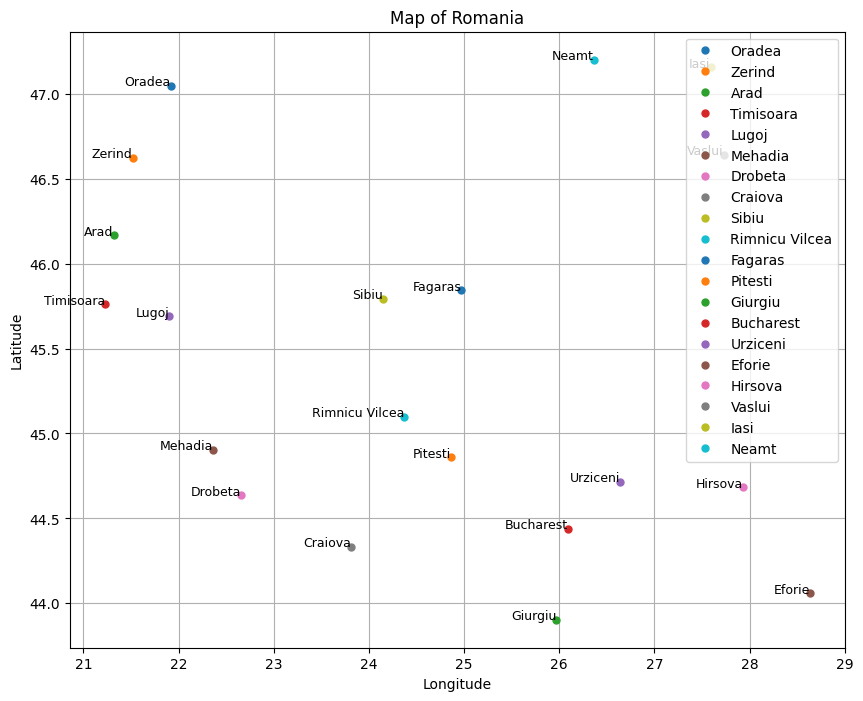

In [20]:
# Map of Romania

import csv
import matplotlib.pyplot as plt

# Load Romania map coordinates from CSV file
def load_romania_coordinates(filename):
    coordinates = {}
    with open(filename, mode='r') as infile:
        reader = csv.reader(infile)
        next(reader)  # Skip header
        for row in reader:
            city = row[0]
            latitude = float(row[1])
            longitude = float(row[2])
            coordinates[city] = (latitude, longitude)
    return coordinates

# Plot Romania map
def plot_romania_map(coordinates):
    plt.figure(figsize=(10, 8))
    for city, (lat, lon) in coordinates.items():
        plt.plot(lon, lat, 'o', markersize=5, label=city)
        plt.text(lon, lat, city, fontsize=9, ha='right')
    plt.xlabel('Longitude')
    plt.ylabel('Latitude')
    plt.title('Map of Romania')
    plt.grid(True)
    plt.legend(loc='best')
    plt.show()

# Example usage
romania_coordinates = load_romania_coordinates('romania_coordinates.csv')
plot_romania_map(romania_coordinates)

In [22]:
# Breadth-First Search (BFS)

def bfs(graph, start, goal):
    visited = set()  # Set to keep track of visited nodes
    queue = [(start, [start])]  # Queue to store the nodes to be explored along with the path

    while queue:
        (vertex, path) = queue.pop(0)  # Dequeue the first node in the queue
        if vertex in visited:
            continue  # Skip if the node has already been visited

        visited.add(vertex)  # Mark the node as visited

        # Iterate over neighbors directly from the graph dictionary
        for neighbor in graph.edges[vertex]:
            if neighbor == goal:
                return path + [neighbor]  # Return the path if the goal is found
            else:
                queue.append((neighbor, path + [neighbor]))  # Enqueue the neighbor nodes

    return None  # Return None if no path is found

# Example usage
start_city = 'Arad'
goal_city = 'Bucharest'


print("BFS:", bfs(romania_graph, start_city, goal_city))


BFS: None


In [23]:
# Depth-First Search (DFS)
def dfs(graph, start, goal):
    visited = set()
    stack = [(start, [start])]
    while stack:
        (vertex, path) = stack.pop()
        if vertex in visited:
            continue
        visited.add(vertex)
        for neighbor in graph[vertex]:
            if neighbor == goal:
                return path + [neighbor]
            else:
                stack.append((neighbor, path + [neighbor]))
    return None
start_city = 'Arad'
goal_city = 'Bucharest'

print("DFS:", dfs(romania_graph, start_city, goal_city))

TypeError: 'Graph' object is not subscriptable